# Notebook 02 — H3 Grid & Network Isochrones
## The 15-Minute Shanghai Project · Track C

This notebook builds the **spatial unit of analysis** and computes **15-minute accessibility** for each of the six
universal needs, by **walking** and **cycling**, using **real street-network distances** (not Euclidean buffers,
following Pozoukidou & Chatziyiannaki, 2021).

**Method.**
1. Tessellate the study area into **Uber H3 resolution-8 hexagons** (~0.74 km², ≈ the 15-min-city neighbourhood scale).
2. Build a routable graph from the Gaode road network (`路网合集`): nodes = snapped intersections, edges = segments weighted by metric length.
3. For each need, run a **multi-source Dijkstra** (SciPy, in C) from *all* POIs of that need with a distance cutoff
   (walk = 4.8 km/h × 15 min = 1200 m; bike = 15 km/h × 15 min = 3750 m). A hexagon **has access** to a need if its
   centre node is within the cutoff.
4. The **baseline score** (0–6) counts how many needs are reachable within 15 minutes **on foot OR by bike**.

## 1. Setup

In [1]:
import sys, time, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, pandas as pd, geopandas as gpd
import shapely, shapely.geometry as sg, h3
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.spatial import cKDTree
from config import SHP_2024, DATA_CLEAN, OUTPUTS, SHANGHAI_BBOX, WALK_KMH, BIKE_KMH, TIME_MIN
warnings.filterwarnings("ignore")
OUTPUTS.mkdir(parents=True, exist_ok=True)
WGS84, METRIC = "EPSG:4326", "EPSG:32651"
SNAP_M = 5
NEEDS = ["alimentation", "sante", "education", "emploi", "loisir_sport", "services"]
CUTOFF = {"walk": WALK_KMH*1000/60*TIME_MIN, "bike": BIKE_KMH*1000/60*TIME_MIN}
print("Cutoffs (m):", {k: round(v) for k, v in CUTOFF.items()})

poi = gpd.read_parquet(DATA_CLEAN / "poi.parquet")
print("POI chargés:", f"{len(poi):,}")

Cutoffs (m): {'walk': 1200, 'bike': 3750}


POI chargés: 737,159


## 2. H3 grid (resolution 8)
Tessellate the study bounding box, then keep only hexagons that are inhabited / road-served (water and empty cells are dropped later).

In [2]:
minx, miny, maxx, maxy = SHANGHAI_BBOX
poly = h3.LatLngPoly([(miny, minx), (miny, maxx), (maxy, maxx), (maxy, minx), (miny, minx)])
cell_ids = list(h3.polygon_to_cells(poly, 8))

def hex_polygon(c):
    return sg.Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(c)])
centers = [h3.cell_to_latlng(c) for c in cell_ids]
hexes = gpd.GeoDataFrame(
    {"cell": cell_ids,
     "clat": [c[0] for c in centers], "clng": [c[1] for c in centers]},
    geometry=[hex_polygon(c) for c in cell_ids], crs=WGS84)
print(f"Hexagones res 8 sur la bbox : {len(hexes):,}")

Hexagones res 8 sur la bbox : 31,853


## 3. Road-network graph (`路网合集`)
Vectorised construction: segment vertices are snapped to a 5 m grid so that coincident intersection endpoints merge into shared nodes. Cached to disk for fast re-runs.

In [3]:
cache = DATA_CLEAN / "road_graph.npz"
if cache.exists():
    z = np.load(cache)
    node_xy, rows, cols, data = z["node_xy"], z["rows"], z["cols"], z["data"]
    print("Graphe chargé du cache.")
else:
    t = time.time()
    roads = gpd.read_file(next(SHP_2024.glob("上海市_路网合集.shp")),
                          engine="pyogrio", columns=[], bbox=SHANGHAI_BBOX).to_crs(METRIC)
    coords, idx = shapely.get_coordinates(roads.geometry.values, return_index=True)
    a, b = coords[:-1], coords[1:]
    same = idx[:-1] == idx[1:]
    a, b = a[same], b[same]
    ka = np.round(a/SNAP_M).astype(np.int64); kb = np.round(b/SNAP_M).astype(np.int64)
    uniq, inv = np.unique(np.vstack([ka, kb]), axis=0, return_inverse=True)
    n = len(a); ia, ib = inv[:n], inv[n:]
    w = np.hypot(a[:, 0]-b[:, 0], a[:, 1]-b[:, 1])
    node_xy = uniq.astype(float) * SNAP_M
    rows = np.concatenate([ia, ib]); cols = np.concatenate([ib, ia]); data = np.concatenate([w, w])
    np.savez(cache, node_xy=node_xy, rows=rows, cols=cols, data=data)
    print(f"Graphe construit en {time.time()-t:.1f}s (cache écrit).")

N = len(node_xy)
G = csr_matrix((data, (rows, cols)), shape=(N, N))
ncomp, labels = connected_components(G, directed=False)
big = np.bincount(labels).max()
print(f"Graphe : {N:,} nœuds, {len(data)//2:,} arêtes | {100*big/N:.1f}% connecté")

Graphe chargé du cache.


Graphe : 597,549 nœuds, 685,985 arêtes | 98.0% connecté


## 4. Snap hexagons & POI to the network

In [4]:
tree = cKDTree(node_xy)

# hexagones : centre -> nœud le plus proche + distance de raccordement
cen = gpd.GeoSeries(gpd.points_from_xy(hexes.clng, hexes.clat), crs=WGS84).to_crs(METRIC)
hsnap, hnode = tree.query(np.c_[cen.x.values, cen.y.values])
hexes["node"] = hnode; hexes["snap_m"] = hsnap

# POI : on part des colonnes lon/lat propres (representative_point en nb01), reprojetées en métrique
pm = gpd.GeoSeries(gpd.points_from_xy(poi["lon"], poi["lat"]), crs=WGS84).to_crs(METRIC)
pxy = np.c_[pm.x.values, pm.y.values]
_, poi_node = tree.query(pxy)
poi = poi.assign(node=poi_node)
print("POI rattachés au réseau. Exemple snap hexagone médian:", f"{np.median(hsnap):.0f} m")

POI rattachés au réseau. Exemple snap hexagone médian: 2707 m


## 5. Network isochrones — accessibility per need (walk & bike)
Multi-source Dijkstra per need: a hexagon reaches a need if `dist[node] + hex_snap ≤ cutoff`.

In [5]:
t = time.time()
for mode, cutoff in CUTOFF.items():
    for need in NEEDS:
        src = np.unique(poi.loc[poi["need"] == need, "node"].values)
        if len(src) == 0:
            hexes[f"{mode}_{need}"] = False; continue
        dist = dijkstra(G, directed=False, indices=src, limit=cutoff, min_only=True)
        d_hex = dist[hexes["node"].values] + hexes["snap_m"].values
        hexes[f"{mode}_{need}"] = d_hex <= cutoff
print(f"12 isochrones calculées en {time.time()-t:.1f}s")

for mode in CUTOFF:
    hexes[f"n_{mode}"] = hexes[[f"{mode}_{n}" for n in NEEDS]].sum(axis=1)
# score baseline = besoins atteignables à pied OU à vélo
for need in NEEDS:
    hexes[f"acc_{need}"] = hexes[f"walk_{need}"] | hexes[f"bike_{need}"]
hexes["baseline_score"] = hexes[[f"acc_{n}" for n in NEEDS]].sum(axis=1)

12 isochrones calculées en 8.9s


## 6. Mask to the inhabited / road-served area
Keep hexagons that contain at least one POI **or** whose centre snaps within 400 m of the network (drops open water and empty cells).

In [6]:
poi_cells = set(poi["cell"]) if "cell" in poi.columns else set(
    h3.latlng_to_cell(la, lo, 8) for la, lo in zip(poi["lat"].values, poi["lon"].values))
mask = hexes["cell"].isin(poi_cells) | (hexes["snap_m"] < 400)
hexes = hexes[mask].reset_index(drop=True)
print(f"Hexagones retenus (zone habitée) : {len(hexes):,}")
print("\nRépartition du score baseline (/6):")
print(hexes["baseline_score"].value_counts().sort_index().to_string())
print(f"\nScore baseline moyen : {hexes['baseline_score'].mean():.2f}/6")
print("Couverture par besoin (walk OR bike):")
for need in NEEDS:
    print(f"  {need:14} {100*hexes[f'acc_{need}'].mean():5.1f}% des hexagones")

Hexagones retenus (zone habitée) : 12,106

Répartition du score baseline (/6):
baseline_score
0     244
1     202
2     184
3     279
4     503
5    1622
6    9072

Score baseline moyen : 5.45/6
Couverture par besoin (walk OR bike):
  alimentation    94.7% des hexagones
  sante           88.8% des hexagones
  education       75.5% des hexagones
  emploi          97.2% des hexagones
  loisir_sport    94.4% des hexagones
  services        94.2% des hexagones


## 7. The 15-minute grid — map
Shanghai tessellated into H3 hexagons, coloured by how many of the six needs are reachable within 15 minutes (walk or bike).

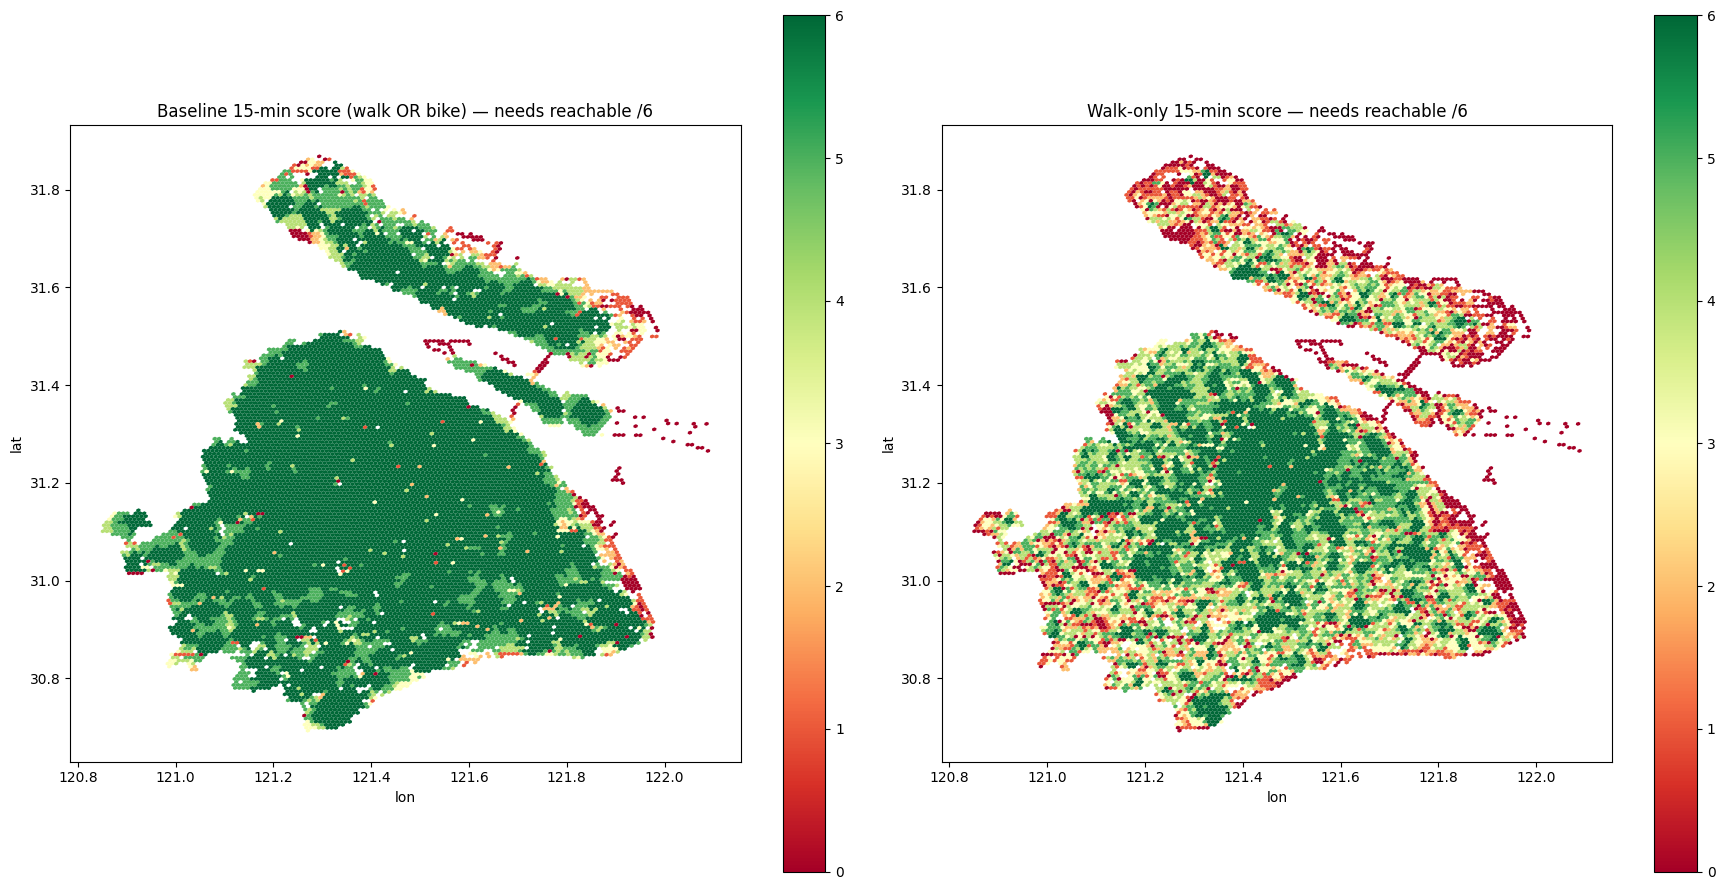

In [7]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
hexes.plot(column="baseline_score", cmap="RdYlGn", vmin=0, vmax=6, legend=True,
           linewidth=0, ax=axes[0])
axes[0].set_title("Baseline 15-min score (walk OR bike) — needs reachable /6")
hexes.plot(column="n_walk", cmap="RdYlGn", vmin=0, vmax=6, legend=True,
           linewidth=0, ax=axes[1])
axes[1].set_title("Walk-only 15-min score — needs reachable /6")
for ax in axes:
    ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 8. Export
`outputs/hexes.geojson` (and parquet) feed the scoring notebook 03 and the Streamlit app.

In [8]:
keep = (["cell", "clat", "clng", "snap_m", "baseline_score", "n_walk", "n_bike"]
        + [f"acc_{n}" for n in NEEDS] + [f"walk_{n}" for n in NEEDS] + [f"bike_{n}" for n in NEEDS])
out = hexes[keep + ["geometry"]].copy()
out.to_file(OUTPUTS / "hexes.geojson", driver="GeoJSON")
out.to_parquet(DATA_CLEAN / "hexes.parquet")
print("Exporté:")
for f in [OUTPUTS / "hexes.geojson", DATA_CLEAN / "hexes.parquet"]:
    print(f"  {f.name:18} {f.stat().st_size/1e6:6.2f} MB | {len(out):,} hexagones")

Exporté:
  hexes.geojson       12.05 MB | 12,106 hexagones
  hexes.parquet        1.77 MB | 12,106 hexagones
